## Location Mapping

In [4]:
# !pip install geopy
import pandas as pd
import numpy as np
import requests, time, math
from pathlib import Path


In [2]:
market_df_4 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_3.csv", encoding='utf-8-sig')
output_csv = "C:/Users/legen/Desktop/Lab Project/BC/data/market_df_4.csv"

In [3]:
# 위도/경도 컬럼 없으면 생성
if "위도" not in market_df_4.columns:
    market_df_4["위도"] = pd.NA
if "경도" not in market_df_4.columns:
    market_df_4["경도"] = pd.NA

# 재실행 이어하기: output_csv가 있으면 그걸 우선 사용
if Path(output_csv).exists():
    market_df_4 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_3.csv", encoding='utf-8-sig')
    if "위도" not in market_df_4.columns:
        market_df_4["위도"] = pd.NA
    if "경도" not in market_df_4.columns:
        market_df_4["경도"] = pd.NA

In [21]:
def kakao_geocode(query: str, api_key: str, timeout: int = 10):
    """query -> (lat, lon) / 실패시 (np.nan, np.nan)"""
    if query is None or (isinstance(query, float) and np.isnan(query)):
        return np.nan, np.nan
    q = str(query).strip()
    if not q:
        return np.nan, np.nan

    headers = {"Authorization": f"KakaoAK {api_key}"}

    # 주소검색
    r = requests.get(
        "https://dapi.kakao.com/v2/local/search/address.json",
        headers=headers, params={"query": q}, timeout=timeout
    )
    if r.status_code == 403:
        raise RuntimeError("Kakao Local API 403: OPEN_MAP_AND_LOCAL(지도/로컬) 서비스 활성화 필요")
    if r.status_code == 200:
        docs = r.json().get("documents", [])
        if docs:
            x, y = docs[0].get("x"), docs[0].get("y")  # x=경도, y=위도
            if x and y:
                return float(y), float(x)

    # 키워드검색 fallback (주소가 애매할 때)
    r2 = requests.get(
        "https://dapi.kakao.com/v2/local/search/keyword.json",
        headers=headers, params={"query": q}, timeout=timeout
    )
    if r2.status_code == 200:
        docs2 = r2.json().get("documents", [])
        if docs2:
            x, y = docs2[0].get("x"), docs2[0].get("y")
            if x and y:
                return float(y), float(x)

    return np.nan, np.nan


In [17]:
def fill_missing_latlon_with_kakao(
    df: pd.DataFrame,
    api_key: str,
    lat_col: str = "위도",
    lon_col: str = "경도",
    query_cols: tuple = ("지번주소", "도로명주소"),
    name_col: str = "사업장명",       # (옵션) 키워드 검색용 보조
    sleep: float = 0.2,              # 너무 빠르면 제한 걸릴 수 있어 약간 딜레이
    verbose: bool = True
) -> pd.DataFrame:
    """
    df에서 lat/lon이 NA인 행만 골라,
    query_cols 순서대로 Kakao geocode 시도 -> 성공 시 lat/lon 채움
    """
    out = df.copy()

    # 위/경도 컬럼 없으면 생성
    if lat_col not in out.columns: out[lat_col] = np.nan
    if lon_col not in out.columns: out[lon_col] = np.nan

    mask = out[lat_col].isna() | out[lon_col].isna()
    idx_list = out.index[mask].tolist()
    total = len(idx_list)

    if verbose:
        print(f"NA 좌표 행: {total}")

    for n, idx in enumerate(idx_list, start=1):
        row = out.loc[idx]

        # 후보 쿼리: 주소들 -> (옵션) 사업장명 + 주소(키워드용) -> 사업장명
        candidates = []
        for c in query_cols:
            v = row.get(c)
            if pd.notna(v) and str(v).strip():
                candidates.append(str(v).strip())

        if name_col in out.columns and pd.notna(row.get(name_col)) and str(row.get(name_col)).strip():
            nm = str(row.get(name_col)).strip()
            if candidates:
                candidates.append(f"{nm} {candidates[0]}")  # 이름+주소(첫 주소)
            candidates.append(nm)

        lat = lon = np.nan
        used = None
        for q in candidates:
            lat, lon = kakao_geocode(q, api_key=api_key)
            if not np.isnan(lat) and not np.isnan(lon):
                used = q
                break

        out.at[idx, lat_col] = lat
        out.at[idx, lon_col] = lon

        if verbose:
            print(f"[{n}/{total}] {'OK' if used else 'FAIL'} | {used}")

        time.sleep(sleep)

    return out

In [19]:
# 카카오맵 API 키
API_KEY = "c4ec06aea3a95e92e9a13e9a748872bf"

In [7]:
market_df_4 = fill_missing_latlon_with_kakao(
    df=market_df_4,
    api_key=API_KEY,
    lat_col="위도",
    lon_col="경도",
    query_cols=("지번주소", "도로명주소"), 
    name_col="시장명",                 
    sleep=0.1,
    verbose=True
)

NA 좌표 행: 840
[1/840] OK | 울산광역시 남구 신정동 630-1
[2/840] OK | 울산광역시 남구 야음동 697-9
[3/840] OK | 울산광역시 남구 야음동 698-1
[4/840] OK | 울산광역시 남구 신정동 634-10
[5/840] OK | 울산광역시 남구 신정동 1600-3 신정평화시장
[6/840] OK | 울산광역시 남구 야음동 815-10
[7/840] OK | 울산광역시 남구 야음동 375-55
[8/840] OK | 울산광역시 남구 삼산동 1591-4 울산산업공구월드
[9/840] FAIL | None
[10/840] OK | 울산광역시 울주군 온양읍 남창리 146 남창옹기종기시장
[11/840] OK | 울산광역시 울주군 온산읍 덕신리 1280-21 덕신종합상설시장
[12/840] OK | 울산광역시 울주군 두동면 봉계리 525
[13/840] OK | 울산광역시 울주군 언양읍 남부리 336-20
[14/840] OK | 울산광역시 울주군 언양읍 남부리 124-2 매일시장상가
[15/840] OK | 울산광역시 울주군 언양읍 남부리 124-2
[16/840] OK | 울산광역시 중구 학성동 432-438
[17/840] OK | 울산광역시 중구 학산동 61-9
[18/840] OK | 울산광역시 중구 반구동 453-39
[19/840] OK | 울산광역시 중구 남외동 257-1 병영시장
[20/840] OK | 울산광역시 중구 서동 38-6 월드빌라트
[21/840] OK | 울산광역시 중구 남외동 385-3 선우시장 선화아파트
[22/840] OK | 울산광역시 중구 성남동 190-239 성남프라자
[23/840] OK | 울산광역시 중구 반구동 100-1
[24/840] OK | 울산광역시 중구 옥교동 125-13
[25/840] OK | 울산광역시 중구 우정동 214-10
[26/840] OK | 울산광역시 중구 성남동 219-119
[27/840] OK | 울산광역시 중구 옥교동 275-4
[28/840]

In [8]:
# 나머지는 심플한 코드로
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geoloc = Nominatim(user_agent="market_geocode_na_fix", timeout=10)
geocode = RateLimiter(geoloc.geocode, min_delay_seconds=1, max_retries=2, error_wait_seconds=3)

na_idx = market_df_4.index[market_df_4["위도"].isna() | market_df_4["경도"].isna()].tolist()
total = len(na_idx)

def safe_str(x):
    return str(x).strip() if pd.notna(x) and str(x).strip() else None
for n, idx in enumerate(na_idx, start=1):
    row = market_df_4.loc[idx]

    candidates = [
        safe_str(row.get("지번주소")),
        safe_str(row.get("도로명주소")),
        " ".join([p for p in [safe_str(row.get("시도")), safe_str(row.get("시군구")), safe_str(row.get("읍면동명"))] if p])
    ]
    candidates = [c for c in candidates if c]  # None 제거

    lat = long = None
    used = None

    for q in candidates:
        geo = geocode(q)
        if geo:
            lat, long = geo.latitude, geo.longitude
            used = q
            break

    market_df_4.at[idx, "위도"] = lat
    market_df_4.at[idx, "경도"] = long

    print(f"[{n}/{total}] idx={idx} {'OK' if lat else 'FAIL'}")

print("# of NA:")
print(market_df_4[["위도","경도"]].isna().sum())

[1/1] idx=8 OK
# of NA:
위도    0
경도    0
dtype: int64


In [9]:
market_df_4[market_df_4['위도'].isna()][["시장명", "지번주소", "위도","경도"]]

market_df_4.to_csv(output_csv, index=False, encoding="utf-8-sig")

## 거리 계산

### 데이터 로드

In [5]:
market_df_4 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_4.csv", encoding='utf-8-sig')

In [8]:
market_df_4 = pd.read_csv(
    r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_4.csv",
    encoding="utf-8-sig"
    )

parking_lot = pd.read_csv(
    r"D:\PP\BC\data\og\location mapping\한국교통안전공단_전국공영주차장정보_20191224.csv",
    encoding="euc-kr"
    )

big_mart = pd.read_excel(
    r"D:\PP\BC\data\og\location mapping\행정안전부_대규모점포.xlsx"
)

bus_stop = pd.read_csv(
    r"D:\PP\BC\data\og\location mapping\2023년_전국버스정류장 위치정보_데이터.csv",
    encoding="euc-kr"
    )

tourist_spot = pd.read_csv(
    r"D:\PP\BC\data\og\location mapping\전국관광지정보표준데이터.csv",
    encoding="euc-kr"
    )

subway = pd.read_excel(
    r"D:\PP\BC\data\og\location mapping\도시철도역사정보.xlsx",
    engine="openpyxl"
)

subway = subway[['역위도', '역경도']]
subway.columns = ['위도', '경도']

In [9]:
import geopandas as gpd

# 편의점
shp_path = r"C:\Users\legen\Downloads\코레일유통(주)_편의점 및 전문점 매장 위치 정보_20251107\코레일유통 편의점 및 전문점 매장 위치 정보.shp"

conv_store = gpd.read_file(shp_path)
conv_store = conv_store[['X', 'Y']]
conv_store.columns = ['경도', '위도']

conv_store.head(3)

,경도,위도
0,127.114712,37.633977
1,127.114712,37.633977
2,127.040616,37.517443


### big mart 전처리: 위도 & 경도 변환, 전통시장 제거, 위도 & 경도 맵핑

In [10]:
big_mart.columns

Index(['번호', '개방서비스명', '개방서비스아이디', '개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자',
       '영업상태구분코드', '영업상태명', '상세영업상태코드', '상세영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자',
       '재개업일자', '소재지전화', '소재지면적', '소재지우편번호', '소재지전체주소', '도로명전체주소', '도로명우편번호',
       '사업장명', '최종수정시점', '데이터갱신구분', '데이터갱신일자', '업태구분명', '좌표정보x(epsg5174)',
       '좌표정보y(epsg5174)', '점포구분명'],
      dtype='object')

In [11]:
# 좌표 수정

# !pip install pyproj
from pyproj import Transformer

# EPSG:5174 → EPSG:4326
transformer = Transformer.from_crs(
    "EPSG:5174",   # 입력 좌표계 (Korea 2000 / Unified CS)
    "EPSG:4326",   # 출력 좌표계 (WGS84)
    always_xy=True
)

# 변환 함수
def epsg5174_to_wgs84(x, y):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    lon, lat = transformer.transform(x, y)
    return lat, lon

big_mart["위도"], big_mart["경도"] = zip(*big_mart.apply(
    lambda r: epsg5174_to_wgs84(
        r["좌표정보x(epsg5174)"],
        r["좌표정보y(epsg5174)"]
    ),
    axis=1
))


In [12]:
big_mart[["좌표정보x(epsg5174)", "좌표정보y(epsg5174)", "위도", "경도"]].head()

,좌표정보x(epsg5174),좌표정보y(epsg5174),위도,경도
0,191152.432649,438865.160717,37.451900,126.900797
1,360141.456259,179926.033758,35.105709,128.757208
2,403214.458028,204878.049675,35.322684,129.235491
3,352870.655049,193192.657446,35.226366,128.679950
4,342886.064849,189864.336046,35.197848,128.569739


In [13]:
# 전통시장이 포함되어 있어서 제거

big_mart = big_mart[
    ~(
        (big_mart["업태구분명"] == "그 밖의 대규모점포") &
        (
            big_mart["사업장명"].str.endswith("시장", na=False) |
            big_mart["사업장명"].str.contains("시장$", na=False) |
            big_mart["사업장명"].str.contains("시장|상점가", na=False)
        )
    )
]

In [14]:
big_mart['사업장명'].head(20)

0                홈플러스 주식회사
1       GS THE FRESH 진해남문점
2              노브랜드 부산아울렛점
3                  이마트 창원점
4                  이마트 마산점
5             진주남부농협 하나로마트
6      GS THE FRESH 송파나루역점
7                      이마트
8     GS THE FRESH 해운대엘시티점
9      GS THE FRESH 인천작전역점
10    GS THE FRESH 대구파크드림점
11      GS THE FRESH 부산시청점
12                성원3차종합상가
13     GS THE FRESH 대구범어역점
14             홈플러스(주) 김제점
15            홈플러스 (주) 인하점
16             홈플러스 인천 숭의점
17          노브랜드 트레이더스 구월점
18     GS TEH FRESH 구월용천로점
19                홈플러스 진해점
Name: 사업장명, dtype: object

In [23]:
# 위도 경도 null값 존재
big_mart[['위도', '경도']].isna().sum()

위도    14
경도    14
dtype: int64

In [ ]:
# 위도경도 Nan 채우기
big_mart = fill_missing_latlon_with_kakao(
    df=big_mart,
    api_key=API_KEY,
    lat_col="위도",
    lon_col="경도",
    query_cols=("소재지전체주소", "도로명전체주소"), 
    name_col="사업장명",                 
    sleep=0.1,
    verbose=True
)

### 계산

In [34]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

EARTH_RADIUS_M = 6371000  # meters

def count_poi_within_radius(market_df, poi_df, market_lat, market_lon, poi_lat, poi_lon, radius_m):
    # 좌표 결측 제거
    df = market_df.dropna(subset=[market_lat, market_lon]).copy()
    poi = poi_df.dropna(subset=[poi_lat, poi_lon]).copy()

    # 라디안 변환
    df_rad = np.deg2rad(df[[market_lat, market_lon]].values.astype(float))
    poi_rad = np.deg2rad(poi[[poi_lat, poi_lon]].values.astype(float))

    # POI가 없으면 전부 0
    if len(poi_rad) == 0:
        out = np.zeros(len(market_df), dtype=int)
        return out

    tree = BallTree(poi_rad, metric="haversine")
    radius = radius_m / EARTH_RADIUS_M  # meters -> radians

    # query_radius는 각 점마다 "인덱스 리스트" 반환 -> 길이가 count
    ind = tree.query_radius(df_rad, r=radius)
    counts_valid = np.array([len(x) for x in ind], dtype=int)

    # 원본 market_df 길이에 맞게 복원 (결측 좌표는 0 처리)
    out = np.zeros(len(market_df), dtype=int)
    out[df.index.values] = counts_valid
    return out


In [48]:
market_df_4["parking"] = count_poi_within_radius(
    market_df=market_df_4,
    poi_df=parking_lot,
    market_lat="위도", market_lon="경도",
    poi_lat="위도", poi_lon="경도",
    radius_m=500
)


market_df_4["bus"] = count_poi_within_radius(
    market_df=market_df_4,
    poi_df=bus_stop,
    market_lat="위도", market_lon="경도",
    poi_lat="위도", poi_lon="경도",
    radius_m=500
)

market_df_4["mart"] = count_poi_within_radius(
    market_df=market_df_4,
    poi_df=big_mart,
    market_lat="위도", market_lon="경도",
    poi_lat="위도", poi_lon="경도",
    radius_m=1500
)

market_df_4["tour"] = count_poi_within_radius(
    market_df=market_df_4,
    poi_df=tourist_spot,
    market_lat="위도", market_lon="경도",
    poi_lat="위도", poi_lon="경도",
    radius_m=5000
)

market_df_4["conv"] = count_poi_within_radius(
    market_df=market_df_4,
    poi_df=conv_store,
    market_lat="위도", market_lon="경도",
    poi_lat="위도", poi_lon="경도",
    radius_m=500
)

market_df_4["subway"] = count_poi_within_radius(
    market_df=market_df_4,
    poi_df=subway,
    market_lat="위도", market_lon="경도",
    poi_lat="위도", poi_lon="경도",
    radius_m=1000
)


In [23]:
market_df_4_1 = add_nearby_counts_by_distance_bins(
    market_df_4,
    parking_lot,
    dist_lists,
    prefix="parking_"
)

market_df_4_2 = add_nearby_counts_by_distance_bins(
    market_df_4_1,
    bus_stop,
    dist_lists,
    prefix="bus_"
)

market_df_4_3 = add_nearby_counts_by_distance_bins(
    market_df_4_2,
    big_mart,
    dist_lists_2,
    prefix="mart_"
)

market_df_4_4 = add_nearby_counts_by_distance_bins(
    market_df_4_3,
    tourist_spot,
    dist_lists_2,
    prefix="tour_"
)

market_df_4_5 = add_nearby_counts_by_distance_bins(
    market_df_4_4,
    conv_store,
    dist_lists,
    prefix="conv_"
)

market_df_4_6 = add_nearby_counts_by_distance_bins(
    market_df_4_5,
    subway,
    dist_lists,
    prefix="subway_"
)

[50/840] processed
[100/840] processed
[150/840] processed
[200/840] processed
[250/840] processed
[300/840] processed
[350/840] processed
[400/840] processed
[450/840] processed
[500/840] processed
[550/840] processed
[600/840] processed
[650/840] processed
[700/840] processed
[750/840] processed
[800/840] processed
[840/840] processed


C:\Users\legen\AppData\Local\Temp\ipykernel_6916\441965134.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[out_cols] = out[out_cols].fillna(0)


[50/840] processed
[100/840] processed
[150/840] processed
[200/840] processed
[250/840] processed
[300/840] processed
[350/840] processed
[400/840] processed
[450/840] processed
[500/840] processed
[550/840] processed
[600/840] processed
[650/840] processed
[700/840] processed
[750/840] processed
[800/840] processed
[840/840] processed
[50/840] processed
[100/840] processed
[150/840] processed
[200/840] processed
[250/840] processed
[300/840] processed
[350/840] processed
[400/840] processed
[450/840] processed
[500/840] processed
[550/840] processed
[600/840] processed


C:\Users\legen\AppData\Local\Temp\ipykernel_6916\441965134.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[out_cols] = out[out_cols].fillna(0)


[650/840] processed
[700/840] processed
[750/840] processed
[800/840] processed
[840/840] processed
[50/840] processed
[100/840] processed
[150/840] processed
[200/840] processed
[250/840] processed
[300/840] processed
[350/840] processed
[400/840] processed
[450/840] processed
[500/840] processed
[550/840] processed


C:\Users\legen\AppData\Local\Temp\ipykernel_6916\441965134.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[out_cols] = out[out_cols].fillna(0)
C:\Users\legen\AppData\Local\Temp\ipykernel_6916\441965134.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[out_cols] = out[out_cols].fillna(0)


[600/840] processed
[650/840] processed
[700/840] processed
[750/840] processed
[800/840] processed
[840/840] processed
[50/840] processed
[100/840] processed
[150/840] processed
[200/840] processed
[250/840] processed
[300/840] processed
[350/840] processed
[400/840] processed
[450/840] processed
[500/840] processed
[550/840] processed
[600/840] processed
[650/840] processed
[700/840] processed
[750/840] processed
[800/840] processed
[840/840] processed
[50/840] processed
[100/840] processed
[150/840] processed
[200/840] processed
[250/840] processed
[300/840] processed
[350/840] processed


C:\Users\legen\AppData\Local\Temp\ipykernel_6916\441965134.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[out_cols] = out[out_cols].fillna(0)


[400/840] processed
[450/840] processed
[500/840] processed
[550/840] processed
[600/840] processed
[650/840] processed
[700/840] processed
[750/840] processed
[800/840] processed
[840/840] processed


C:\Users\legen\AppData\Local\Temp\ipykernel_6916\441965134.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[out_cols] = out[out_cols].fillna(0)


### 결과

<Axes: >

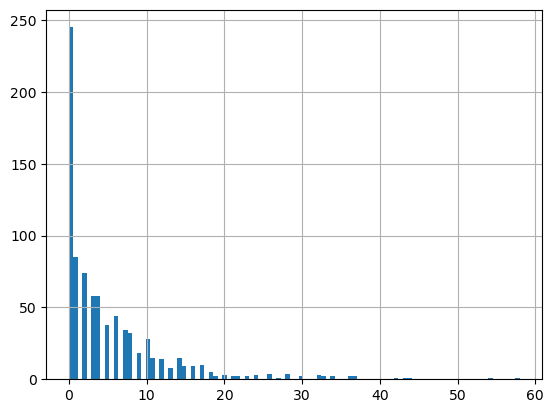

In [49]:
market_df_4['parking'].hist(bins = 100)

### 저장

In [51]:
market_df_4.columns

Index(['Unnamed: 0', '시장명', '지번주소', '도로명주소', '시도', '시군구', '아케이드 보유 여부',
       '엘리베이터_에스컬레이터_보유여부', '고객지원센터 보유 여부', '스프링쿨러 보유 여부', '화재감지기 보유여부',
       '유아놀이방_보유여부', '종합콜센터_보유여부', '고객휴게실_보유여부', '수유센터_보유여부', '물품보관함_보유여부',
       '자전거보관함_보유여부', '체육시설_보유여부', '간이 도서관_보유여부', '쇼핑카트_보유여부', '외국인 안내센터_보유여부',
       '고객동선통로_보유여부', '방송센터_보유여부', '문화교실_보유여부', '공동물류창고_보유여부',
       '시장전용 고객주차장_보유여부', '교육장_보유여부', '회의실_보유여부', '자동심장충격기_보유여부', '시장면적',
       '전체점포', '빈점포', '기타점포', '노점수', '점포상인', '종업원', '노점상인', '총시장상인', '지원금액',
       '지원여부', 'has_assoc', 'join_stores', 'delivery', 'grocery',
       'item_diversity', 'is_food_based', 'has_nonfood', 'fresh_count',
       'nonfood_count', 'market_item_type', 'dong_guess', 'dong_guess_je',
       '행정기관코드', 'match_status', 'pop_t', 'pop_m', 'pop_f', 'pop_adole',
       'pop_young', 'pop_middle', 'pop_senior', '위도', '경도', 'parking', 'bus',
       'mart', 'tour', 'conv', 'subway'],
      dtype='object')

In [52]:
market_df_4 = market_df_4.drop(columns = ['Unnamed: 0', 'dong_guess','dong_guess_je', 'match_status'
                                              #, '시군구_변환여부'
                                              ])

In [53]:
market_df_4.columns

Index(['시장명', '지번주소', '도로명주소', '시도', '시군구', '아케이드 보유 여부', '엘리베이터_에스컬레이터_보유여부',
       '고객지원센터 보유 여부', '스프링쿨러 보유 여부', '화재감지기 보유여부', '유아놀이방_보유여부', '종합콜센터_보유여부',
       '고객휴게실_보유여부', '수유센터_보유여부', '물품보관함_보유여부', '자전거보관함_보유여부', '체육시설_보유여부',
       '간이 도서관_보유여부', '쇼핑카트_보유여부', '외국인 안내센터_보유여부', '고객동선통로_보유여부', '방송센터_보유여부',
       '문화교실_보유여부', '공동물류창고_보유여부', '시장전용 고객주차장_보유여부', '교육장_보유여부', '회의실_보유여부',
       '자동심장충격기_보유여부', '시장면적', '전체점포', '빈점포', '기타점포', '노점수', '점포상인', '종업원',
       '노점상인', '총시장상인', '지원금액', '지원여부', 'has_assoc', 'join_stores', 'delivery',
       'grocery', 'item_diversity', 'is_food_based', 'has_nonfood',
       'fresh_count', 'nonfood_count', 'market_item_type', '행정기관코드', 'pop_t',
       'pop_m', 'pop_f', 'pop_adole', 'pop_young', 'pop_middle', 'pop_senior',
       '위도', '경도', 'parking', 'bus', 'mart', 'tour', 'conv', 'subway'],
      dtype='object')

In [54]:
market_df_4.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_5.csv"
                     , index=False, encoding="utf-8-sig", index_label=False)


In [55]:
market_df_4.shape

(840, 65)

## 시각화

In [65]:
import folium
import pandas as pd
import numpy as np
from geopy.distance import geodesic

def _clean_and_maybe_swap_latlon(df, lat_col, lon_col, name="poi"):
    x = df.copy()
    x[lat_col] = pd.to_numeric(x[lat_col], errors="coerce")
    x[lon_col] = pd.to_numeric(x[lon_col], errors="coerce")
    x = x.dropna(subset=[lat_col, lon_col]).copy()

    # WGS84 범위 내 비율 계산
    lat_ok = x[lat_col].between(-90, 90).mean()
    lon_ok = x[lon_col].between(-180, 180).mean()

    # swap했을 때의 범위 내 비율
    lat_ok_swapped = x[lon_col].between(-90, 90).mean()
    lon_ok_swapped = x[lat_col].between(-180, 180).mean()

    # swap이 더 자연스러우면 교체
    if (lat_ok_swapped + lon_ok_swapped) > (lat_ok + lon_ok):
        x = x.rename(columns={lat_col: "__lon__", lon_col: "__lat__"})
        x[lat_col] = x["__lat__"]
        x[lon_col] = x["__lon__"]
        x = x.drop(columns=["__lat__", "__lon__"])
        print(f"[{name}] swapped lat/lon columns: {lat_col}<->{lon_col}")

    # 최종 범위 밖 제거
    x = x[x[lat_col].between(-90, 90) & x[lon_col].between(-180, 180)].copy()
    return x

def folium_bus_count_map(
    market_df,
    poi_df,
    radius_m=500,
    zoom_start=13,
    market_name_col="시장명",
    market_lat_col="위도",
    market_lon_col="경도",
    poi_lat_col="위도",
    poi_lon_col="경도",
    max_poi_draw=3000  # 지도에 점 너무 많이 찍는 거 방지
):
    results = []

    # 시장 좌표 정리
    mk = _clean_and_maybe_swap_latlon(market_df, market_lat_col, market_lon_col, name="market")
    # POI 좌표 정리(+swap 자동)
    poi = _clean_and_maybe_swap_latlon(poi_df, poi_lat_col, poi_lon_col, name="poi")

    poi_coords = poi[[poi_lat_col, poi_lon_col]].values

    for _, mall in mk.iterrows():
        mall_coord = (float(mall[market_lat_col]), float(mall[market_lon_col]))

        m = folium.Map(location=mall_coord, zoom_start=zoom_start)

        # 시장 표시
        folium.Marker(
            location=mall_coord,
            popup=str(mall.get(market_name_col, "market")),
            icon=folium.Icon(color="red", icon="info-sign")
        ).add_to(m)

        # 반경 원
        folium.Circle(
            location=mall_coord,
            radius=radius_m,
            color="red",
            fill=True,
            fill_opacity=0.2
        ).add_to(m)

        cnt = 0
        drawn = 0

        for lat, lon in poi_coords:
            # 안전 범위 체크
            if not (-90 <= lat <= 90 and -180 <= lon <= 180):
                continue

            try:
                d = geodesic(mall_coord, (lat, lon)).meters
            except Exception:
                continue

            if d <= radius_m:
                cnt += 1
                # 지도 렌더링 과부하 방지: 일정 개수까지만 찍기
                if drawn < max_poi_draw:
                    folium.CircleMarker(
                        location=(lat, lon),
                        radius=3,
                        color="black",
                        fill=True,
                        fill_opacity=1
                    ).add_to(m)
                    drawn += 1

        results.append({
            market_name_col: mall.get(market_name_col, None),
            f"bus_{radius_m}m": cnt
        })

        display(m)

    return pd.DataFrame(results)


In [66]:
bus_count_df = folium_bus_count_map(
    market_df=market_df_4,
    poi_df=bus_stop,
    radius_m=500
)


KeyboardInterrupt: 